In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/raw/SampleSuperstore.csv")

In [7]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [9]:
df.shape

(9994, 13)

In [12]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [13]:
df.info

<bound method DataFrame.info of            Ship Mode    Segment        Country             City       State  \
0       Second Class   Consumer  United States        Henderson    Kentucky   
1       Second Class   Consumer  United States        Henderson    Kentucky   
2       Second Class  Corporate  United States      Los Angeles  California   
3     Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4     Standard Class   Consumer  United States  Fort Lauderdale     Florida   
...              ...        ...            ...              ...         ...   
9989    Second Class   Consumer  United States            Miami     Florida   
9990  Standard Class   Consumer  United States       Costa Mesa  California   
9991  Standard Class   Consumer  United States       Costa Mesa  California   
9992  Standard Class   Consumer  United States       Costa Mesa  California   
9993    Second Class   Consumer  United States      Westminster  California   

      Postal Code R

In [14]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [16]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [18]:
df["Sales"].sum()

np.float64(2297200.8603)

In [19]:
df["Profit"].sum()

np.float64(286397.0217)

In [20]:
df["Sales"].mean()

np.float64(229.85800083049827)

In [21]:
df["Sales"].max()

np.float64(22638.48)

In [22]:
df["Sales"].min()

np.float64(0.444)

In [23]:
(df["Profit"] < 0).sum()

np.int64(1871)

In [24]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [25]:
df.groupby("Category")["Profit"].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [26]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [31]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [36]:
df.groupby("Sub-Category")["Sales"].sum()

Sub-Category
Accessories    167380.3180
Appliances     107532.1610
Art             27118.7920
Binders        203412.7330
Bookcases      114879.9963
Chairs         328449.1030
Copiers        149528.0300
Envelopes       16476.4020
Fasteners        3024.2800
Furnishings     91705.1640
Labels          12486.3120
Machines       189238.6310
Paper           78479.2060
Phones         330007.0540
Storage        223843.6080
Supplies        46673.5380
Tables         206965.5320
Name: Sales, dtype: float64

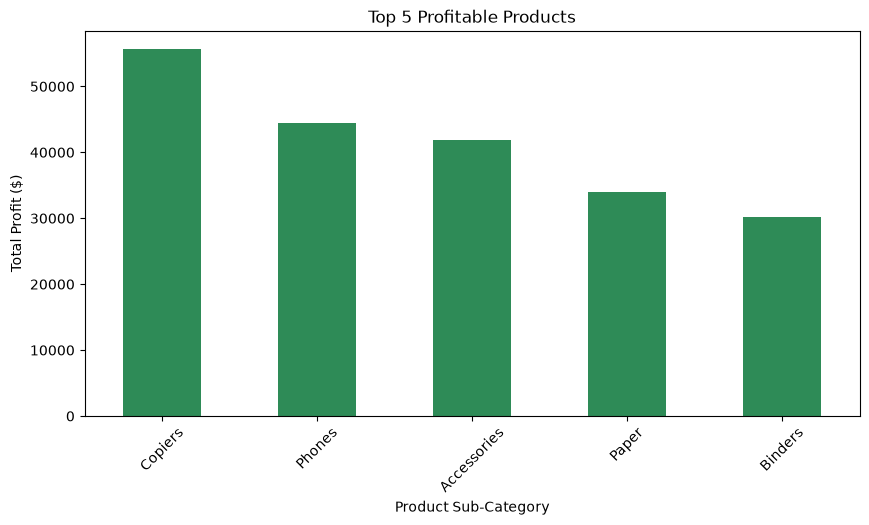

In [65]:
# Calculate the top 5 profitable products
top_5 = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).head(5)

# Set the figure size
plt.figure(figsize=(10, 5))

# Create a bar chart using Pandas plot method
top_5.plot(kind="bar", color="seagreen")

# Add title and labels
plt.title("Top 5 Profitable Products")
plt.xlabel("Product Sub-Category")
plt.ylabel("Total Profit ($)")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

### 🏆 Top 5 Profitable Products Report

**① Business Question:**
Which products generate the most profit for the company?

**② Analysis:**
We grouped the data by Sub-Category and used a Bar Chart to highlight the top 5 products with the highest total profit.

**③ Insight:**
* **Copiers** are the most profitable product by a large margin (over $55,000).
* **Phones** and **Accessories** follow in second and third place.
* Surprisingly, low-cost everyday office items like **Paper** and **Binders** made it to the top 5. This means they sell in very high volumes and are a very stable source of income.

**④ Recommendation:**
* Invest more in marketing and special offers for **Copiers** and **Phones**, as they bring the highest returns per sale.
* Ensure the warehouse is always fully stocked with **Paper** and **Binders** to keep this steady cash flow running without any out-of-stock issues.

In [71]:
tables = df[df["Sub-Category"] == "Tables"]
tables.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
10,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,1706.1840,9,0.20,85.3092
24,Standard Class,Consumer,United States,Orem,Utah,84057,West,Furniture,Tables,1044.6300,3,0.00,240.2649
117,Standard Class,Consumer,United States,Seattle,Washington,98103,West,Furniture,Tables,787.5300,3,0.00,165.3813
125,Standard Class,Consumer,United States,Bloomington,Illinois,61701,Central,Furniture,Tables,617.7000,6,0.50,-407.6820


In [72]:
tables.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,319.000000,319.000000,319.000000,319.000000,319.000000
mean,58331.749216,648.794771,3.890282,0.261285,-55.565771
std,32271.739155,615.774655,2.446381,0.169622,230.565006
min,1841.000000,24.368000,1.000000,0.000000,-1862.312400
25%,27716.000000,244.006000,2.000000,0.200000,-122.829300
50%,61107.000000,447.840000,3.000000,0.300000,-31.372200
75%,90036.000000,872.170000,5.000000,0.400000,33.851700
max,99207.000000,4297.644000,13.000000,0.500000,629.010000


In [73]:
tables.shape

(319, 13)

In [74]:
tables["Profit"].describe()

count     319.000000
mean      -55.565771
std       230.565006
min     -1862.312400
25%      -122.829300
50%       -31.372200
75%        33.851700
max       629.010000
Name: Profit, dtype: float64

In [75]:
tables["Profit"].min()

np.float64(-1862.3124)

In [76]:
tables[tables["Profit"] == tables["Profit"].min()]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9639,Second Class,Consumer,United States,Concord,North Carolina,28027,South,Furniture,Tables,4297.644,13,0.4,-1862.3124


In [77]:
tables["Discount"].describe()

count    319.000000
mean       0.261285
std        0.169622
min        0.000000
25%        0.200000
50%        0.300000
75%        0.400000
max        0.500000
Name: Discount, dtype: float64

In [78]:
tables.groupby("Discount")["Profit"].mean()

Discount
0.00    184.393051
0.20     -4.275465
0.30    -63.006067
0.40   -215.831957
0.45   -226.646464
0.50   -239.316314
Name: Profit, dtype: float64

In [79]:
tables.groupby("Discount")["Profit"].count()

Discount
0.00    72
0.20    71
0.30    54
0.40    75
0.45    11
0.50    36
Name: Profit, dtype: int64

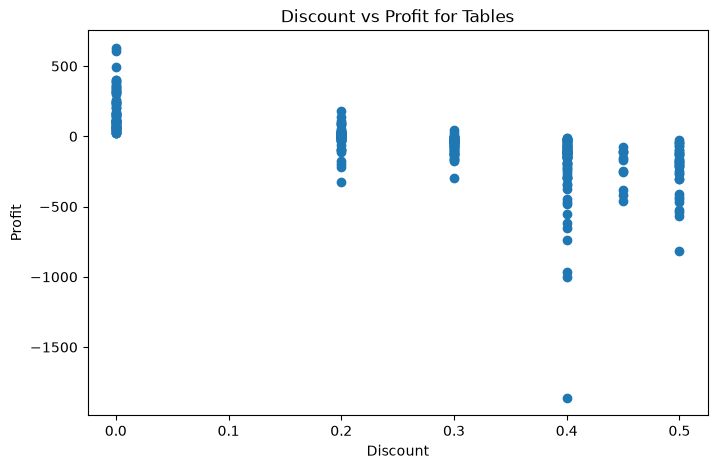

In [80]:
plt.figure(figsize=(8, 5))

plt.scatter(tables["Discount"], tables["Profit"])

plt.title("Discount vs Profit for Tables")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### 📊 Tables Sales Analysis Report

**① Business Question:**
Are high discounts causing the money loss in Tables sales?

**② Analysis:**
We used a Scatter Plot to see how the Discount percentage affects the Profit for each order.

**③ Insight:**
There is a clear negative relationship between discounts and profits for Tables:
* At **0% discount**, all sales make a positive profit.
* When the discount goes **above 20%**, profits start to drop.
* At **40% and 50% discounts**, every single sale causes a big loss for the company.

**④ Recommendation:**
* Stop giving discounts higher than 20% on Tables immediately.
* Set a maximum limit (cap) on discounts to make sure the company keeps a positive profit margin.

In [84]:
losing_products = df[df["Sub-Category"].isin(["Bookcases", "Supplies"])]
loss_analysis = losing_products.groupby(["Sub-Category", "Discount"])["Profit"].mean()
loss_analysis

Sub-Category  Discount
Bookcases     0.00        101.261862
              0.15         27.288298
              0.20          2.837004
              0.30        -55.587260
              0.32        -88.560656
              0.50       -236.433983
              0.70       -259.662627
Supplies      0.00         14.687130
              0.20        -39.828681
Name: Profit, dtype: float64

### 🚨 Losing Products Investigation (Bookcases & Supplies)

**① Business Question:**
Are discounts also causing the losses in Bookcases and Supplies, just like Tables?

**② Analysis:**
We filtered the data to show only Bookcases and Supplies, then grouped by Sub-Category and Discount to see the average profit at each discount level.

**③ Insight:**
The data proves that high discounts are the root cause of losses across all losing categories:
* **Bookcases:** Profit remains positive up to a 20% discount. However, at a 30% discount, the average profit drops to -$55, and plummets to -$259 at a 70% discount.
* **Supplies:** This category is highly sensitive. At 0% discount, it makes a profit of $14. But just a 20% discount turns it into a $39 loss.

**④ Recommendation:**
* **Bookcases:** Apply a strict discount cap of 15% to keep a safe profit margin.
* **Supplies:** Completely ban all discounts on this category. It cannot survive any price cuts.

In [90]:
# Group by Region, calculate total profit, and sort from highest to lowest
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

# Print the exact numbers
print("Profit by Region:")
print(region_profit)

Profit by Region:
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


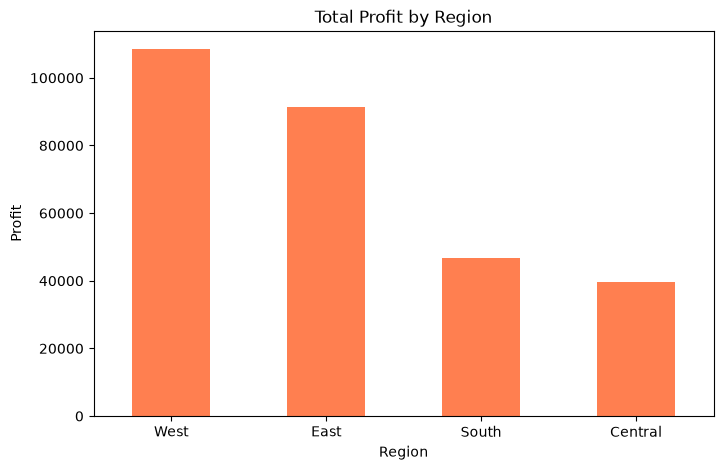

In [92]:
# Set the figure size
plt.figure(figsize=(8, 5))

# Create a bar chart to visualize the regional profit
region_profit.plot(kind="bar", color="coral")

# Add title and labels
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

# Keep the x-axis labels horizontal for easy reading
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [94]:
# Calculate the average discount given in each region
region_discount = df.groupby("Region")["Discount"].mean().sort_values(ascending=False)

# Display the result
print("Average Discount by Region:")
print(region_discount)

Average Discount by Region:
Region
Central    0.240353
South      0.147253
East       0.145365
West       0.109335
Name: Discount, dtype: float64


### 🔍 Root Cause Analysis: Why is the Central region struggling?

**① Hypothesis:**
Are high discount rates responsible for the low profits in the Central region?

**② Analysis:**
We calculated the average discount applied in each of the four regions.

**③ Insight:**
* The hypothesis is **100% correct**. 
* The **Central** region gives the highest average discount (**24%**), which destroys its profit margin.
* In contrast, the **West** region (our most profitable region) strictly controls its discounts, giving the lowest average (only **11%**).
* This confirms that the company's profitability is directly tied to controlling discount rates.

**④ Recommendation:**
* The Central region management must immediately adopt the West region's pricing strategy.
* Cap regional discounts at a maximum average of 10-15% to restore healthy profit margins in the Central region.

In [97]:
segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

# Print the exact numbers
print("Profit by Customer Segment:")
print(segment_profit)

Profit by Customer Segment:
Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


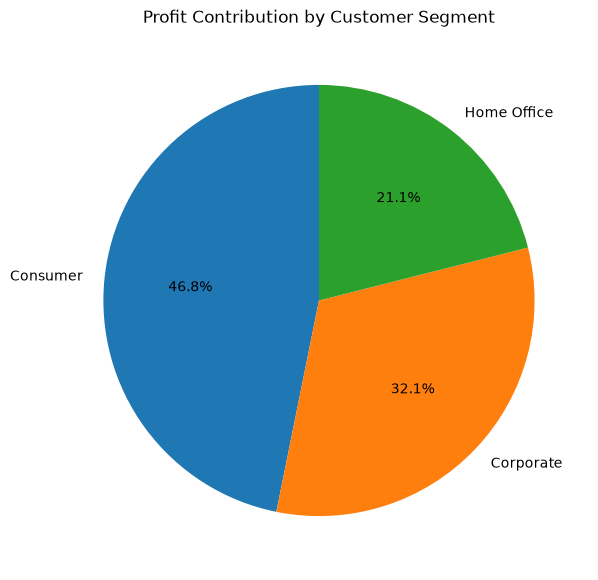

<Figure size 640x480 with 0 Axes>

In [104]:
# Set the figure size
plt.figure(figsize=(7, 7))

# Create a pie chart
segment_profit.plot(kind="pie", autopct='%1.1f%%', startangle=90)

# Add title and clean up the y-label
plt.title("Profit Contribution by Customer Segment")
plt.ylabel("")  # Removes the default 'Profit' text on the side

# Display the chart
plt.show()

# Save the plot to the images folder
plt.savefig("../images/segment_profit_pie.png", bbox_inches='tight', dpi=300)

### 👥 Customer Segments Profitability Report

**① Business Question:**
Which type of customers (Segment) brings the most profit to the company?

**② Analysis:**
We grouped the data by `Segment` and calculated the total profit. We used a Pie Chart to easily see the percentage each segment contributes to the total profit.

**③ Insight:**
* The **Consumer** segment is the absolute winner, bringing in almost half of the total profit (**46.8%** or ~$134,000).
* The **Corporate** segment is in second place, contributing around a third of the profit (**32.1%** or ~$92,000).
* The **Home Office** segment is the smallest, contributing only **21.1%** (~$60,000).

**④ Recommendation:**
* Focus the majority of the marketing budget and advertising on the **Consumer** segment, as they are the main driver of the company's success.
* Create special B2B (Business to Business) loyalty programs to encourage the **Corporate** segment to buy more and increase their 32% share.

In [103]:
# Export data directly to the existing 'cleaned' folder using a relative path
df.to_excel("../data/cleaned/cleaned_techmart_data.xlsx", index=False, engine="openpyxl")

# Export to CSV as well
df.to_csv("../data/cleaned/cleaned_techmart_data.csv", index=False)

print("Data exported successfully to the 'cleaned' folder! 🎉")

Data exported successfully to the 'cleaned' folder! 🎉
